In [46]:
#1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [47]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [48]:
from google.colab import files

print("Please upload the dataset.csv file:")
files.upload()

Please upload the dataset.csv file:


Saving part_3_nlp_sequence_modeling-20260517T155147Z-3-001.zip to part_3_nlp_sequence_modeling-20260517T155147Z-3-001 (2).zip


{'part_3_nlp_sequence_modeling-20260517T155147Z-3-001 (2).zip': b'PK\x03\x04\x14\x00\x08\x08\x08\x00*\xbb\xa3\\\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00/\x008\x00part_3_nlp_sequence_modeling/data_dictionary.mdup4\x00\x01oI\xc7_part_3_nlp_sequence_modeling/data_dictionary.mdUR\xc1n\xdb0\x0c\xbd\xfb+\x08\xe4\xdat\x87\xddzl\x8a\x0c\x03\xda\xa0h2\xech\xd3\x12\xed\x08\x91%O\xa4\xb2e_?Jq\r\xec"H\xe2{\x8f\x8fO\xda\xc0;&\x81\xaf\xf0\x82\x82L\xf2\x04\xbb\xcc\x12\'Jp\xcc\xf3\x1c\xb5v\xa2?\x02;\x8f\xccnp\x06\xc5\xc5\xf0\x89n\x9a\xcd\x06\xf6\xceS\xd3\x99\x85\xd6\xf2\x9d\xd6\x8a\xd2Z\xf3\x1f\xed\xd1\xf0\xb5\xab\x9co\x11}\xf3\x9c\x9d\xb7\x80\x01\x0e\xaf\xef0EK\x1e$\xc2B\xb9\xc1\xa7"L\xc4\x8c#1\xf47`\n\xe2&]\x1e\xab\xce\t\xd3H\xea.\xfa<\x85f\x0b\xddZo=\xf6\xe4\xbb\'\xe8\xe6\xc8N\xdc\x95\xba\x07\xe8\x02eI\xe8u\x1bS9\x8dX+U\xeb\x07\xd3\x90\xfd\xa2\xc5El\x9diq\xa0j.\xccY\xa0\xcc\x06\x83J\xac\xce+\xfc\x8c!\xd4\x9e\x1cs2\x04\xcb\x05\xc4\x01\xe4L \xce\\43E\xfe\x8e\xc9\xb6&\xe6 \n\xb6\x94\xd4\x83\xbd

In [49]:
import zipfile
import os

zip_file_name = 'part_3_nlp_sequence_modeling-20260517T155147Z-3-001.zip'

if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('/content/')
    print(f"'{zip_file_name}' unzipped successfully to '/content/'")
else:
    print(f"Error: '{zip_file_name}' not found. Please ensure the correct zip file was uploaded.")

'part_3_nlp_sequence_modeling-20260517T155147Z-3-001.zip' unzipped successfully to '/content/'


In [50]:
#2. Load Dataset
df = pd.read_csv('/content/part_3_nlp_sequence_modeling/customer_support_text_classification.csv')

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [51]:
#3. Dataset Understanding
print("Number of Records:", len(df))

print("\nTarget Classes:")
print(df['sentiment_label'].unique())

print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

# Average text length
df['text_length'] = df['customer_message'].apply(len)

print("\nAverage Text Length:")
print(df['text_length'].mean())

# Sample Records
print("\nSample Text:")
print(df['customer_message'].head())

Number of Records: 1500

Target Classes:
['neutral' 'positive' 'negative']

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Average Text Length:
72.75666666666666

Sample Text:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


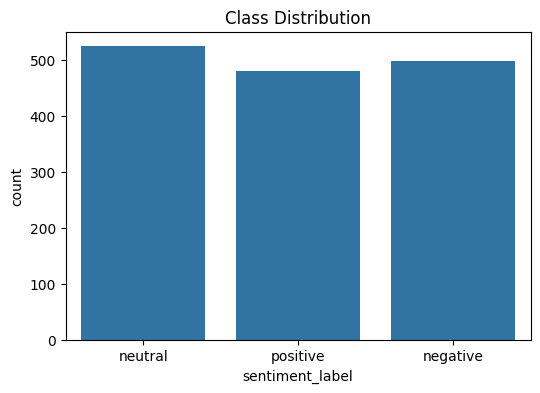

In [52]:
#4. Visualize Class Distribution
plt.figure(figsize=(6,4))

sns.countplot(x=df['sentiment_label'])

plt.title('Class Distribution')

plt.savefig('model_evaluation.png')

plt.show()

In [53]:
#5. Text Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9\\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

df['clean_text'] = df['customer_message'].apply(preprocess_text)

df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,ineedinformationaboutthepaymentprocessmyticket...
1,I need information about the payment process.,ineedinformationaboutthepaymentprocess
2,The refund process was fast and convenient. I ...,therefundprocesswasfastandconvenientiappreciat...
3,My refund is still pending and this experience...,myrefundisstillpendingandthisexperienceisfrust...
4,Please tell me how to update my account details.,pleasetellmehowtoupdatemyaccountdetails


In [54]:
#6. TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])

y = df['sentiment_label']

In [55]:
#7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
#8. Baseline Model – Logistic Regression
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [57]:
#9. Predictions
y_pred = model.predict(X_test)

In [58]:
#10. Model Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7766666666666666

Classification Report:

              precision    recall  f1-score   support

    negative       0.62      1.00      0.76       109
     neutral       1.00      0.66      0.80       104
    positive       1.00      0.63      0.77        87

    accuracy                           0.78       300
   macro avg       0.87      0.77      0.78       300
weighted avg       0.86      0.78      0.78       300



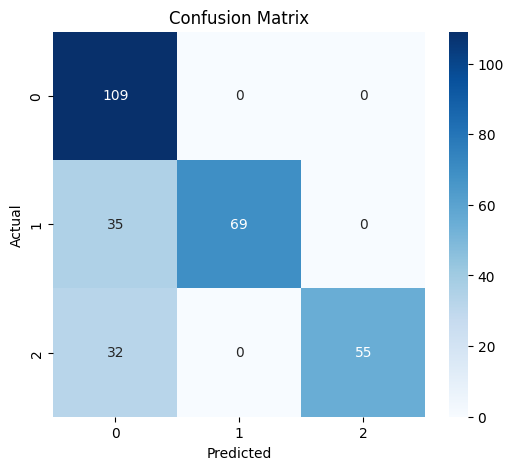

In [59]:
#11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [60]:
#12. Save Sample Predictions
sample_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

sample_df.head(20).to_csv(
    'sample_predictions.txt',
    index=False
)

print(sample_df.head(20))

      Actual Predicted
0    neutral   neutral
1   positive  positive
2    neutral   neutral
3   negative  negative
4   negative  negative
5   negative  negative
6   negative  negative
7    neutral   neutral
8   negative  negative
9   negative  negative
10  negative  negative
11  negative  negative
12  negative  negative
13   neutral   neutral
14  negative  negative
15  negative  negative
16  positive  positive
17   neutral   neutral
18  negative  negative
19  negative  negative


In [61]:
#13. Sequence Modeling – Tokenizer
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [62]:
#14. Padding Sequences
max_length = 100

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [63]:
#15. Train-Test Split for Sequence Model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Convert sentiment labels to numerical format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Convert numerical labels to one-hot encoded format
y_one_hot = to_categorical(y_encoded)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    padded_sequences,
    y_one_hot,
    test_size=0.2,
    random_state=42
)

In [64]:
#16. LSTM Model
num_classes = len(np.unique(y_encoded))
lstm_model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=max_length),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax') # Changed to num_classes and softmax for multi-class
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [65]:
#17. Compile Model
lstm_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Changed to categorical_crossentropy for multi-class
    metrics=['accuracy']
)
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
#18. Train LSTM Model
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.3469 - loss: 1.0999 - val_accuracy: 0.3292 - val_loss: 1.0991
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.3552 - loss: 1.0982 - val_accuracy: 0.3292 - val_loss: 1.0998
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.3552 - loss: 1.0982 - val_accuracy: 0.3292 - val_loss: 1.0996
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.3552 - loss: 1.0985 - val_accuracy: 0.3292 - val_loss: 1.0995
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.3552 - loss: 1.0979 - val_accuracy: 0.3292 - val_loss: 1.0997


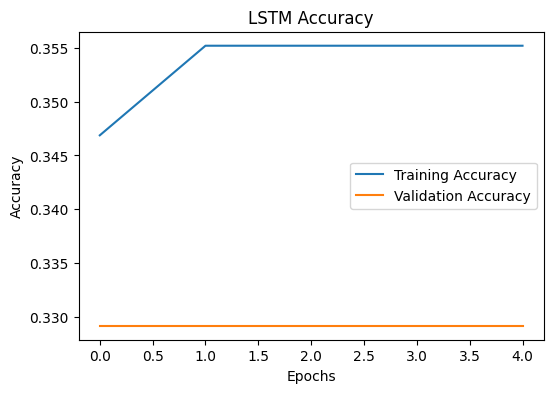

In [67]:
#19. Plot Accuracy Curve
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('LSTM Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [68]:
from google.colab import files

# Download result files
files.download('model_evaluation.png')
files.download('sample_predictions.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>